<a href="https://colab.research.google.com/github/Chase-Troy/Course-Assignments/blob/main/Hamlet_Word_Frequency.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EXERCISE 12.6 – Word Frequency & Word Cloud from HAMLET

Imports

In [34]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from collections import Counter
from textblob import TextBlob
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np

Import txt file (gutenberg.txt)

In [35]:
import requests

target_url = "https://www.gutenberg.org/files/2265/2265-0.txt"
response = requests.get(target_url)
text = response.text

Download NLTK resources

In [36]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

Text preprocessing (with custom stopwords)

In [37]:
blob = TextBlob(text)
text = blob.raw.lower()

tokens = word_tokenize(text)

custom_stop = {
    'hamlet','ham','king','lord',
    'laertes','laer','polonius','horatio',
    'claudius','ophelia',
    'thy','thou','thee','shall','may',
    'let','sir','oh','enter','exit'
}

stop_words = set(stopwords.words('english')).union(custom_stop)

lemmatizer = WordNetLemmatizer()

clean_words = [
    lemmatizer.lemmatize(word)
    for word in tokens
    if word.isalpha() and word not in stop_words
]

print("Total clean words:", len(clean_words))

Total clean words: 13915


Top-20 Word Frequency

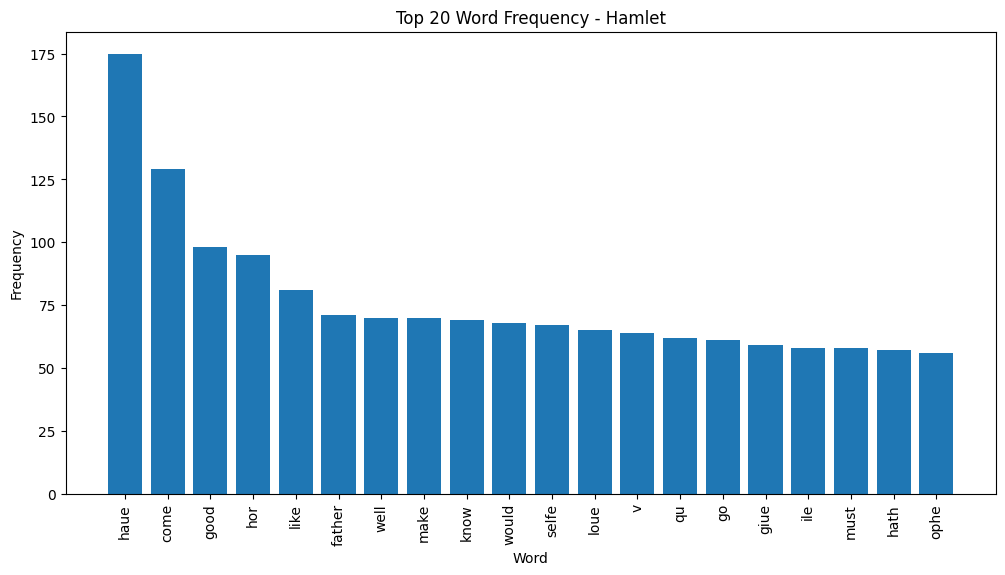

In [38]:
word_counts = Counter(clean_words)
top20 = word_counts.most_common(20)

words, counts = zip(*top20)

plt.figure(figsize=(12,6))
plt.bar(words, counts)
plt.xticks(rotation=90)
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.title("Top 20 Word Frequency - Hamlet")
plt.show()

Create Oval Mask (words INSIDE oval)

In [39]:
y, x = np.ogrid[:800, :800]

center_x, center_y = 400, 400
radius_x, radius_y = 350, 250

oval = ((x - center_x)**2 / radius_x**2 +
        (y - center_y)**2 / radius_y**2 <= 1)

mask_array = np.ones((800, 800), dtype=np.uint8) * 255
mask_array[oval] = 0

Generate Word Cloud

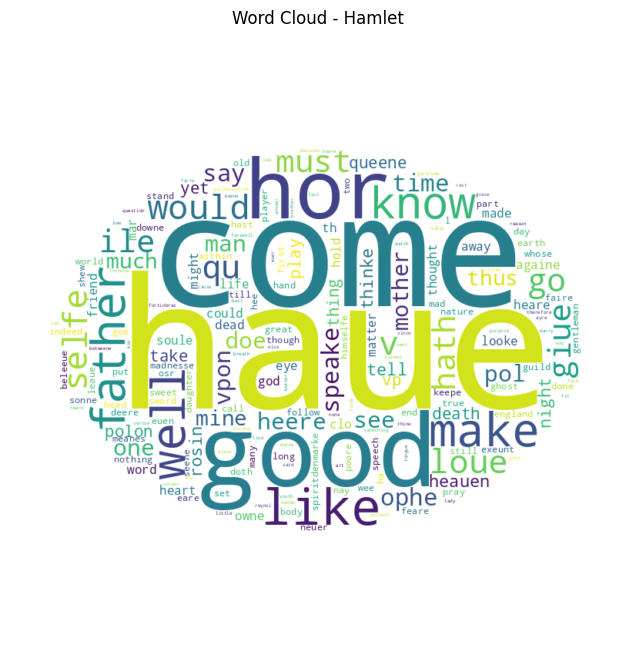

In [40]:
wordcloud = WordCloud(
    width=800,
    height=800,
    background_color='white',
    mask=mask_array
).generate_from_frequencies(word_counts)

plt.figure(figsize=(8,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud - Hamlet")
plt.show()